# Problemimiz:

Bu aşamada spor müsabakasının özet halinin tam halinde nereye denk geldiğini bulmaya çalışacağız.

Burada özet videoda var olmayı önemli olmanın işareti olarak kabul edebiliriz. Eğer özetin her parçasını maçta nereye düştüğünü bulabilirsek, maçın hangi anlarının önemli olduğunu otomatik olarak çıkartabiliriz.

Bu özetleme modelinin eğitmek için gerekli olan ground-truth etiketini verir.

Peki neden ses ?

  - sesi işlemek görüntüye göre çok daha kolaydır. bir video karesi yüz binlerce pikselden (genişlik x yükseklik x renk kanalı) oluşur. Ses ise tek bir boyutludur. Bu sebeple sesi işlemek kat kat daha hızlıdır.
  
  - Ses re-encode'da göre çok daha dayanıklıdır. Videolar arşivlenirken farklı codeclerle tekrar tekrar sıkıştırılır. Bu da pikselleri ciddi bozar. Ses codecleri ise (AAC, MP3) psikoakustik maskeleme ile çalışır. Yani kulağın fark edemediği zayıf bileşenleri atar, güçlü sesleri neredeyse birebir korur.

  - Bilgi seste daha yoğundur. Ayırt edici bilgi tam da önemli anlarda,ses en güçlü haliyle bulunur.


# Waveform

Ses bilgisayarda bir sayı dizisi olarak tutulur. Her sayı o anki genlik, yani havanın ne kadar sıkıştığını gösterir. Buna da waveform (dalga formu) denir.

Amacımız basitce şudur, özetin waveform'unu al, full maçın dalgası boyunca kaydıra kaydıra nerede çok örtüşüyor bunu bulmaya çalışacağız. En çok örtüşen yer, bizim hizalama noktamız olacaktır. - Cross-correlation -

Fakat birkaç problemimiz var:

  - Cross-correlation çok yavaştır. Özeti full maçın her olası konumunda kaydırıp her seferinde örtüşmeyi hesaplar. Bu da O( n x m) karmaşıklığa sahiptir. n: full maçın sample sayısı, m: özetin sample sayısı

  - Kırılganlık :) . cross correlation'da iki dalga birebir aynı varsayar. çünkü cross-correlation, iki dalganın sample değerlerini çarpıp toplayarak örtüşmeyi ölçer. Ama gerçek senaryoda tekrar encode etmek sesin sample değerlerini değiştirir. Eğer 2 ses farklı codec'lerden geçerse dalga değerleri tutmaz. Ayrıca farklı codecler sesin seviyesi (gain) de farklı kılar. Ve faz kayması. Milisaniyelik hizalama farkları bile sample'ları kaydırır.


Yani kısaca, hem hızlı hem de değişime dayanıklı bir model hazırlamalıyız. Bunun için sesin değişmez bir yapısal kimliğine bakmalıyız. Gain değişse, re-encode olsa da, faz kayması olsa bile pattern'i aynı kalması gerek.

Sesin kimliği ise genlik değerinde değil, frekansında yatar. Bu anda hangi frekanslar çalıyor bilgisi, gainden ve re-encode'dan çok daha sağlam kalır.

Yani hedefimiz, sesi genlikten bağımsız, frekans temelli bir temsile çevirmek. Bunun için doğrudan frekans nedir, sesi frekansa nasıl çeviririz sorusuna bakacağız.

Çünkü frekans içeriği dayanıklıdır. Aynı spiker aynı sesi çıkardığında, gain veya sıkıştırma değişse bile frekans deseni (hangi frekanslar baskın) korunur — değişen sadece o frekansların şiddeti olur, deseni değil.


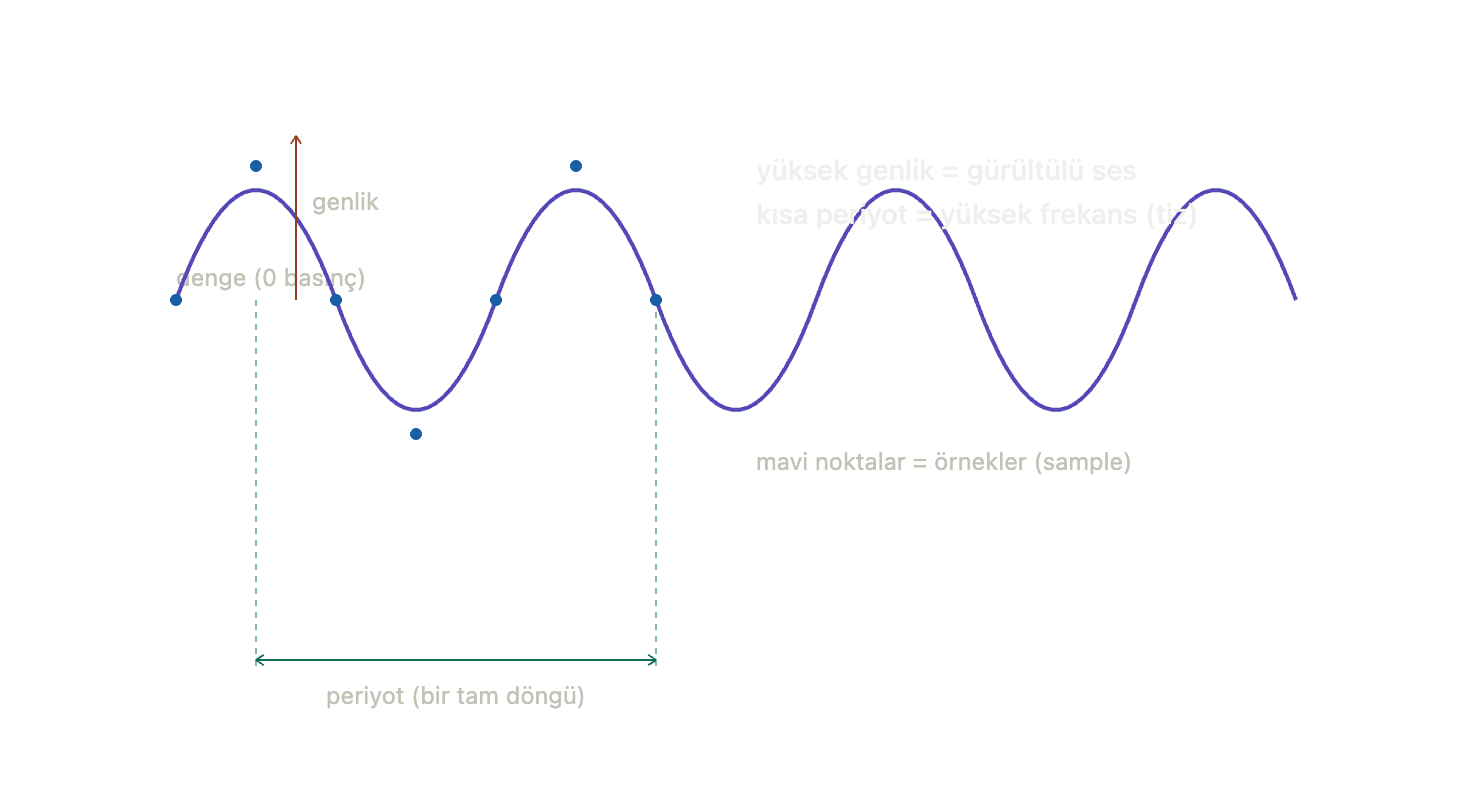

Sesin temellerine bakacak olursak, ses havadaki bir basınç dalgasıdır. Grafikteki eğri de tam da budur: hava basıncının zamanla yukaı - aşağı salınmasıdır.

- Genlik (amplitude) bu dalganın denge çizgisinden tepeye ya da çukura olan uzaklığıdır. Büyük genlik = gürültü, küçük genlik ise = kısık sestir.

waveform (kod'da y ile göstereceğiz) içindeki her sayı ise bu genlik değeridir.
Gain artışı bu genlikliri dikeyde uzatır. Yani genlik en kolay değişen şeydir ve pek de güvenilmez bir boyutdur. Bu sebeple bu modelimizi genlikten bağımsız kurmak istiyoruz.

- Periyot ise dalgadaki bir tam döngünün tamamlanma süresidir, birimi saniye.

- Frekans ise periyodun tersidir. Yani saniyede kaç döngü tamamlandığı, birimi Hz. Eğer frekans düşük ise ses kalın, bas. frekans yüksek ise tiz, ince ses çıkar.

Sesi kimliği frekansta saklıdır. Frekans deseni her daim aynı kalır.


# Sampling

Gerçek ses sürekli bir analog dalgadır, yani zamanda sonsuz noktası bulunur ve bir pc bu sonsuz noktayı saklayamaz. Bu sebeple bu sonsuz noktalı dalgayı belirli aralıklarla ölçeriz, örnekleriz.

**sample rate** saniyede kaç ölçüm alındığıdır, birimi hertz. (kod'da bunu sr olarak göstereceğiz)

buradan şunu çıkartabiliriz:

sample sayısı / sample rate = saniye cinsinden süre


Şu ana kadar elimizde bir waveform (y) yani zaman-genlik verimiz var. Fakat bize ise "bu anda hangi frekanslar var" bilgisi gerekiyor. Ve bunu waveform'a bakarak doğrudan okuyamayız. Bunun için Fourier dönüşümü yapacağız.


In [59]:
import librosa

filename = librosa.example("trumpet")

# waveform ve sample rate
y, sr = librosa.load(filename)

# librosa.load default olarak sesi mono'ya çevirir. (N, ) dizi verir.
print("waveform: ", y.shape)

# librosa.load default olarak sesi 22050 Hz'ye örnekler.
print("sembol rate: ", sr)

# waveform / sr = saniye
print("saniye cinsinden süre: ", len(y) / sr)


waveform:  (117601,)
sembol rate:  22050
saniye cinsinden süre:  5.333378684807256


# Fourier Transform

Fourier şunu iddia eder:

**Karmaşık bir dalga, farklı frekanslardaki basit bir sinüs dalgalarının toplamı olarak yazılabilir**

Bir örnek verecek olursak, bir orkestra düşünebiliriz. Havada tek bir karışık basınç dalgası var. Biz bunu tek bir waveform olarak duyarız. Aslında o dalganın içerisinde 440 Hz keman sesi + 100 Hz bas sesi + 800 Hz zil sesi... gibi seslerden oluşmakta. Yani hepsi üst üste binmiş hali.

Fourier dönüşümü bu üst üste binmiş toplamı geri ayrıştırır. Yani bu karmaşık dalganın içinde 400 Hz'den şu kadar , 100 Hz den bu kadar var der.

Fourier'in cıktısına ise spektrum diyeceğiz. Yatayda frekans, dikeyde ise o frekanstan ne kadar güçlü olduğunu göreceğiz. Yani aslında hangi frekanstan ne kadar var tablosu gibi.

## Short Term Fourier Transform

Fakat saf Fourier'in bir kusuru var, zamanı yok eder. Yani bu seste şu kadar 400 hz 'den şu kadar var der fakat, bunun ne zaman olduğunu söylemez. Ses ekseni kaybolur.

Bunu ise STFT - Short Term Fourier Transform - ile çözeceğiz. Yani tüm sese birden Fourier uygulamak yerine sesi önce küçük parçalara bölüp daha sonra her parçaya ayrı ayrı Fourier uygulayacağız. Böylece her küçük parça için bu kısa an aralığında hangi frekanslar var bilgisine ulasabiliriz..

STFT mekanizmamız şu adımları içerecek:

 1. Sesin başına sample cinsinden küçük bir pencere koy. (kodda n_fft diyeceğiz).
 2. O pencere içerisindeki sese Fouirer uygula. Sonucunda o an için bir frekans spektrumu elde edeceğiz. Bu total spektrumun bir sütunu olacak.
 3. Pencereyi biraz kaydıracağız (kodda hop_length olarak isimlenecek) ve tekrar Fourier uygulayacağız.
 4. Bu döngüyü sesin sonuna gelene kadar devam ettireceğiz.


Sonuçta her sütun bir "an"ın frekans fotoğrafı olacak. Sütunları yan yana dizince → zaman-frekans haritası, yani spektrogram meydana gelecektir.

Biraz kodlayalım:


In [60]:
stft = librosa.stft(y, n_fft=512, hop_length=128)
print(stft.shape)
# 919: pencereyi 919 kez kaydırdık ve her kaydırma için bir spektrum elde ettik.
# 257: her pencerenin Fourier'i 257 frekans bandı verdi.

# peki neden 257 ?
# formül: n_fft / 2 + 1 = 257.
# yani Fourier, n_fft sample'lık bir pencereden bu kadar ayrı frekans bin'i çıkarabilir.
# her bin belli bir frekans aralığını temsil eder.
# en alt bin= 0Hz, en üst bin Nyquist frekansı: 11025hz. (sr / 2)

(257, 919)


Burada önemli bir tasarım kararımız olacak. Çünkü pencere boyutu (n_fft) bir ikilem yaratmakta.:

  - Geniş bir pencere seçilirse, çok fazla sample olacaktır. Böylece Fourier frekansı ince ayırt edebilir ve frekans çözünürlüğü iyi olacaktır. Fakat pencere geniş bir aralığı kapsar, ve frekansın zaman çözünürlüğü bulanıklaşır.

  - Dar bir pencere seçilirse, zamanda dar bir aralığa bakılır, böylece olayın tam ne zaman olduğunu yakalar. Fakat içerisinde az sample olduğu için Fourier frekansı kabaca yakalar. Yani frekans çözünürlüğü o kadar da iyi olmaz.

ayrıca hop_length yani pencerenin her ne kadar kayacağını belirleyen parametre de bir tasarım kararıdır:

  - Küçük bir hop_length seçilirse pencereler çok üst üste biner, zaman ekseninde çok sütun çıkar. Böylece zaman çözünürlüğümüz keskinleşir fakat hesaplama çok artar.

  - Büyük bir hop_length ise daha az sütun, fakat daha hızlıdır.


Peki STFT'nin sonucunda biz ne elde ediyoruz ? Bir karmaşık sayı. Bu da şu iki bilgiyi taşır:

  1. Büyüklük (Magnitude) : √(a² + b²) → o frekanstan ne kadar var (enerji/şiddet)

  2. Faz(phase): o noktanın açısı.

Yukarıda bahsettiğimiz üzere faz ile pek bir işimiz yok. Robustness için ondan kurtulabiliriz.



In [61]:
import numpy as np

magnitude = np.abs(stft)
print(magnitude.shape)
print(magnitude[0, :5])

(257, 919)
[0.002192   0.00149843 0.0037924  0.00219678 0.00281366]


# Logaritmik (dB) ölçek

Daha sonra elde ettiğimiz magnitude'u dB'ye çeviririz. Peki neden ?

Ses enerjisi çok büyük bir aralığa yayılır. Bazı frekanslar diğerlerinin milyon katı olup onları bastırabilir. Bu bastırma hem görselleştirme de hem de peak seçiminde (ileride bahsedeceğiz) büyük bir sorundur.

Logaritma bu geniş aralığı sıkıştırır. İnsan kulağı da zaten sesi logaritmik algılar. (bu sebeple dB ile ölçülür)

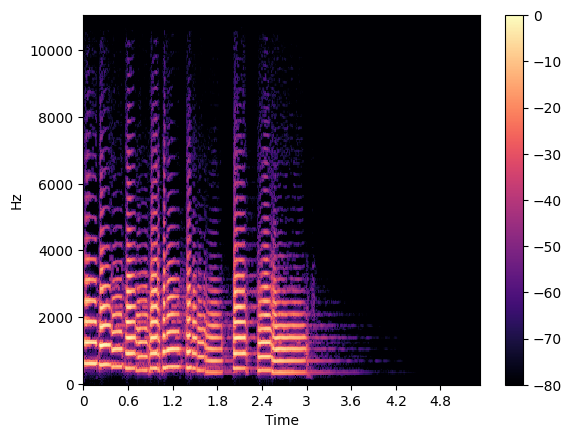

In [62]:
import matplotlib.pyplot as plt

db = librosa.amplitude_to_db(magnitude, ref=np.max(magnitude))
# ref=np.max(stft_magnitude) => en yüksek değeri 0 db kabul eder.
# Geri kalan herşey ona göre negatif dB kalır.
# Bu yüzden peak eşiği negatif bir sayıdır ve bu ancak dB ölçeğinde anlamlıdır.

img = librosa.display.specshow(db, sr=sr, hop_length=128, x_axis="time", y_axis="hz")
plt.colorbar(img)
plt.show()


# Local Maximums

Elimizde 257 x 1309221 boyutunda bir db spektrumu var. Yaklaşık olarak 336 milyon. Bu değerlerin her biri bir enerji değeridir. Fakat değer çok fazla ve gürültü içermekte. BU şekilde pek işimize yaramaz. Peki ne yapacağız ?

Shazam programında da olduğu gibi **sadece yerel enerji tepelerini tut, geri kalan her şeyi at** yapacağız.

Sonuç olarak elde ettiğimiz şey yoğun bir db spektrumu yerine, zaman-frekans düzleminde bulunan birkaç nokta olacak. Bu da yıldız haritasını andırdığı için
constellation map deniyor.

Peki neden tepe noktalarını, peaks, seçiyoruz ?

  1. Yeniden encode etmeye dayanıklıdır. Lossy codec'ler psikoakustik maskeleme ile çalısırdı. Yani güçlü bir sesin gölgesinde kalan zayıf bileşenleri atar, güçlü olanları büyük ölçüde korurdu. Yani sıkıştırma işleminden sağ kalanlar tepe noktalarıdır.

  2. Local max. asla değişmez. yani ses seviyesi %10 bile artsa tüm hücreler birlikte artacağı için local max değişmez.

  3. Seyreklik bize hız sağlayacaktır.


Peki peak dediğimiz şey nedir ?

Aslında peak noktaları, etrafındaki komşularından daha yüksek, güçlü olan noktalardır. Peki etrafından kastımız nedir ? işte burada da bir tasarım kriteri daha oluşuyor: **komşuluk penceresi**

komşuluk penceresi, her hücrenin etrafında ±f frekans, ±t zaman içinde taranan bölge. Eğer ki bir hücre bu pencere içerisinde en büyük, en güçlü hücre ise o bir yerel maksimum'dur.

Dediğimiz gibi komşuluk penceresi bir tasarım kararıdır. Bu parametre constellation'ın yoğunluğunu ayarlar. (kod'da buna size olarak değerlendireceğiz)

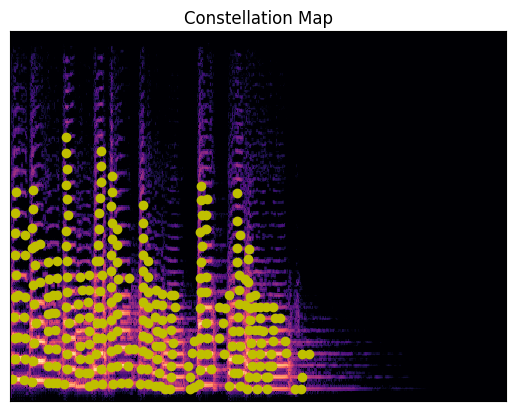

In [63]:
import scipy

constellation_matrix = scipy.ndimage.maximum_filter(db, size=10) # size = komsuluk parametresi

# mask = (db == komşuluk_maksimumu) ->
# Bir hücre nerede kendi komşuluk-maksimumuna eşitse, orası local-max'tır.

# ayrıca bir eşik değeri de koyarız.
# peak, belli bir enerji eşiğinin de üstünde olmalı.
# ayrıca tam sessizlik anında anlamsız peak'ler cıkar.
# esik degeri bunları da engeller
mask = (db == constellation_matrix) & (db > -40)

# bu aslında bir mask'dir. bunu cons_matrix'e uygulayacağız.
peaks = np.argwhere(mask)

img = librosa.display.specshow(db,sr=sr, hop_length=128)
plt.scatter(peaks[:, 1], peaks[:, 0], c = "y") # 0 = frekans, 1= zaman indeksi
plt.title("Constellation Map")
plt.show()

# [frekans, zaman]. Örneğin [120, 47]:
# "120. frekans bin'inde, 47. zaman frame'inde bir peak var."

# Peak Eşleştirme

Hem özet, hem de full video için Constellation Map hazır diyebiliriz. Yani zaman frekans düzleminde binlerce (frekans, zaman) noktaları.

Amacımız ise özetteki bir frekans desenini, full maçtaki aynı desenle eşleştirmek, ama HIZLICA. yani bir arama yapacağız, bunun içinde bize bir anahtar(key) değer lazım.

Akla ilk gelen brute-force yöntem peakleri eşleştirmek olur. Fakat bu işe yaramaz çünkü aynı frekansta binlerce peak noktası olabilir. Bizim aradığımız sahnenin sahip olduğu frekansa benzer ama tamamen farklı sahneler ile eşleştirme yapma ihtimalimiz var. Yani peak-peak araması yapmamız işe yaramaz ki, çok da maliyetlidir.

## Anchor - Target Nokta Çiftleri

Çözümü nokta çiftleri oluşturarak yapcağız. İlk olarak bir peak seçeceğiz, anchor. Bu noktanın ileri zamanında başka bir peak daha seçeceğiz, target. Bunlar arasındaki ilişkiyi yani zaman farkını kaydedeceğiz. Yani her seçtiğimiz (anchor, target) çifti bize şunu döndürecek: **(f1, f2, Δt)**

  - f1: anchor'un frekansı
  - f2: target frenaksı
  - Δt: target zamanı - anchor zamanı (zaman farkı)

Artık bu üçlü için mutlak zamandan çıkıp, iki peak arasında göreli zaman farkını tutuyoruz. Peki neden ? Spikerin "GOOOL" bağırışı, full maçın 1200. saniyesinde de, özetin 45. saniyesinde de aynı (f1, f2, Δt) desenini verir — çünkü iki peak arasındaki ilişki değişmez, sadece bulundukları mutlak konum değişir.

## Target Zone - Peak

Peki bir anchor'u hangi target'lar ile eşleyeceğiz ? İki kısıt koyacağız.

  a. **Zaman Penceresi (Δt):** Δt_min ile Δt_max arası değerler ile eşleyebiliriz. Δt_min genelde 1 alınır, Δt_max ise çok yüksek alınmamalıdır. O peak'in ilerideki bir peak ile pek alakası olmaz

  b. **Fan-out**: Target zone içerisinde onlarca peak olabilir. Hepsi ile çiftlemeya kalkarsak bu sefer oluşturacağımız hash sayısı patlar. Bu yüzden bir :fan_out kadar sınır koyacağız.

Bu iki parametre, veritabanının boyutunu ve hızını belirler. Yüksek fan-out = daha çok hash = daha dayanıklı eşleşme ama daha yavaş/büyük. Düşük fan-out = hızlı ama gürültüde daha kırılgan.

## Hashing

Elimizde üç sayıdan oluşan bir veri var. Bunu arama yapmak için tek bir anahtar istiyoruz. Çünkü dict - yani hash table tek sayı ile arama anlıktır -> O(1)

Çözüm, üc alanı bit kaydırma ile tek bir integer'a sıkıştırırz. Her alana sabit bir bit genişliği ayırıp yan yana dizeriz.

Örn:
hash = f1 × 2¹⁵ + f2 × 2⁶ + Δt
Burdaki üstellerin anlamı nedir ?

f1,f2 frekans bin'idir. maksimum 256 alabilir ve 257 farklı bin olabilir (0-256). 256'yı temsil etmek için kaç bit gerekir ? 2^8 = 256. Burada 9 bit güvenli alıyoruz.

Δt zaman farkıdır. maksimum t_max = 50 olarak tanımlamıştık. 50 sayısını 2^6 ile temsil edebiliriz.

Yani bitlerin yerleşimine baktığımızda Δt en küçük değer oldukları için en alttaki bitlere otururlar. hemen üstüne f2 kaydırılır yani 2^6. en üste de f1 kalır yani 2^15. hash = (f1 << 15) | (f2 << 6) | del_t

Kritik kural: her alanın kendi bölgesine ayrılan bit, o alanın maksimum değerini taşıyabilecek kadar geniş olmalı — yoksa alanlar birbirine taşar (overflow), farklı üçlüler aynı hash'i üretir (istenmeyen collision).


## Hash Tablosu

Şimdi arama yapacağımız hash tablosunu oluşturabiliriz.

- **Anahtar(key)** = hash: Yani (f1, f2Δt) paketlenmiş hâli. Konumdan bağımsız unique bir değer.

- Değer (value)** = Anchor'un mutlak zamanı. Yani mutlak zamanı kaybetmiyoruz, değer olarak tutuyoruz (kodda t_anchor olarak tutacağız.)


Yani:
- Göreli olan (Δt) → hash'in içinde → anahtar tarafında
- Mutlak olan (t_anchor) → hash'in dışında → değer tarafında

Değerleri bir liste olarak tutmalıyız. Çünkü aynı hash, full maçta birden çok yerde çıkabilir, collision. Bu bir hata değildir. Örneğin benzer bir ses deseni maçın 8. ve 27. frame'inde tekrarlanmışsa, ikisi de aynı hash'i üretir. Mesela düdük, top, salon akustiğinin sesi gibi aynı sesleri çıkarır.


In [64]:
# ilk olarak peak'leri zamana göre sıralamamız gerekiyor.
# eaks = np.argwhere(mask) bize çıktı olarak frekans öncelikli bir sıralı verdi,
# fakat biz bunu zaman sıralı olmasını istiyoruz.
# peaks[:, 0] -> frekans bin indexleri
# peaks[:, 1] -> zaman frame indexi

sorted_peaks = np.argsort(peaks[:, 1])
peaks = peaks[sorted_peaks]
print(peaks[: 10])


[[ 15   4]
 [ 58   7]
 [130   8]
 [101   8]
 [ 72   8]
 [ 43   8]
 [ 29   9]
 [116   9]
 [ 87  10]
 [145  11]]


In [65]:
# hashing
def fingerprints(peaks, t_min, t_max, fan_out):
  """peaks (zaman-sıralı) -> (hash, mutlak_zaman) çiftleri listesi.
Hem full hem özet için çağrılır."""
  pairs = []

  for anchor in peaks:
    t_anchor = anchor[1] # mutlak zaman
    f1 = anchor[0]

    target_zone = peaks[
        (peaks[:, 1] >= t_anchor + t_min) &
        (peaks[:, 1] <= t_anchor + t_max)
    ]

    target_zone = target_zone[:fan_out]

    for target in target_zone:
      f2 = target[0]
      del_t = target[1] - t_anchor # goreli zaman

      hash_value = (((f1 << 15) | (f2 << 6) | del_t))
      pairs.append( (hash_value, t_anchor) )

  return pairs


In [66]:
T_MIN = 1
T_MAX = 50
FAN_OUT = 5


pairs = fingerprints(peaks, T_MIN, T_MAX, FAN_OUT)
print(pairs[: 5])


[(np.int64(495235), np.int64(4)), (np.int64(499844), np.int64(4)), (np.int64(497988), np.int64(4)), (np.int64(496132), np.int64(4)), (np.int64(494276), np.int64(4))]


Bu kısa sesimizde - trumpet - 88 peak bulduk ve sorunsuz calıstı. Fakat gerçek bir ses verisi ile calıstığımızda, örneğin gerçek bir basketbol maçı 55.772 peak, bu kod biraz eksik kaldı. Peki neden:





```
target_zone = peaks[
    (peaks[:, 1] >= t_anchor + t_min) &
    (peaks[:, 1] <= t_anchor + t_max)
]
```

bu satır her çağrıldığında tüm peak dizisi baştan sona taranıyor. Her elaman iki koşullu şartı sağlayıp sağlanmadığına bakılıyor. Bunun maliyeti her anchor için n. n tane de anchor olduğunu düşünürsek n x n = n². Yani gerçek veri de mantıksız bir işlem. Başka bir çözüm yolu bulacağız.

# Searchsorted Update - BinarySearch

Yukarıda zaten peaks dizimizi zamana göre sıralamıştık. İlk versiyonumuzda bunu hiç kullanmadık. Oysa sıralı bir dizi çok kuvvetlidir ve ikili arama - binary search - algoritmasını kullanabiliriz. Böylece maliyet n yerine logn'e düşer. Yani sayısal olarak 55.772 için konuşacak olursak; 55.772 yerine sadece 16 işlem yapacağız :)

Bu mekanizmada target zone'u bu sekilde bulacağız:

- start = searchsorted(times, t_anchor+dt_min, side='left')

- end = searchsorted(times, t_anchor+dt_max, side='right')

- target_zone = peaks[start:end]

In [67]:
T_MIN = 1
T_MAX = 50
FAN_OUT = 5

def fingerprints_v2(peaks, t_min, t_max, fan_out):
  """peaks (zaman-sıralı) -> (hash, mutlak_zaman) çiftleri listesi.
  Hem full hem özet için çağrılır."""
  pairs = []
  times = peaks[:, 1] # searchsorted tek boyutlu dizi ister (zaman sütunu)

  for anchor in peaks:
    t_anchor = anchor[1]
    f1 = anchor[0]

    start = np.searchsorted(times, t_anchor + t_min, side="left")
    end = np.searchsorted(times, t_anchor + t_max, side="right")
    target_zone = peaks[start:end]

    target_zone = target_zone[: fan_out]

    for target in target_zone:
      f2 = target[0]
      del_t = target[1] - t_anchor

      hash_value = (((f1 << 15) | (f2 << 6) | del_t))
      pairs.append( (hash_value, t_anchor) )

  return pairs



In [68]:
eski = fingerprints(peaks, T_MIN, T_MAX, FAN_OUT)
yeni = fingerprints_v2(peaks, T_MIN, T_MAX, FAN_OUT)
print(eski == yeni)   # aynı olmalı

True


In [69]:
# hash table olusturma

def create_hashTable(pairs):

  hash_table = {}

  for (hash, zaman) in pairs:
    hash_table.setdefault(hash, []).append(zaman)

  return hash_table

hash_table = create_hashTable(pairs)
hash_table

{np.int64(495235): [np.int64(4)],
 np.int64(499844): [np.int64(4)],
 np.int64(497988): [np.int64(4)],
 np.int64(496132): [np.int64(4)],
 np.int64(494276): [np.int64(4)],
 np.int64(1908865): [np.int64(7)],
 np.int64(1907009): [np.int64(7)],
 np.int64(1905153): [np.int64(7), np.int64(26)],
 np.int64(1903297): [np.int64(7)],
 np.int64(1902402): [np.int64(7), np.int64(26), np.int64(269), np.int64(422)],
 np.int64(4261697): [np.int64(8)],
 np.int64(4267265): [np.int64(8)],
 np.int64(4265410): [np.int64(8)],
 np.int64(4269123): [np.int64(8)],
 np.int64(4264518): [np.int64(8)],
 np.int64(3311425): [np.int64(8)],
 np.int64(3316993): [np.int64(8)],
 np.int64(3315138): [np.int64(8)],
 np.int64(3318851): [np.int64(8)],
 np.int64(3314246): [np.int64(8)],
 np.int64(2361153): [np.int64(8), np.int64(27)],
 np.int64(2366721): [np.int64(8)],
 np.int64(2364866): [np.int64(8)],
 np.int64(2368579): [np.int64(8)],
 np.int64(2363974): [np.int64(8)],
 np.int64(1410881): [np.int64(8)],
 np.int64(1416449): [np

Elimizde full sesten oluşmuş bir hash table'mız var. Bir de aynı sesten yapay bir özet olusturalım.

In [70]:
baslangic = 1.5
bitis = 2.5

ozet_db_matris = db[:, 258:430] # 1.5 - 2.5 sn arası


# consellation_matrix

ozet_cons = scipy.ndimage.maximum_filter(ozet_db_matris, size=10)
ozet_mask = (ozet_db_matris == ozet_cons) & (ozet_db_matris > -40)

ozet_peaks = np.argwhere(ozet_mask)
sorted_ozet_peaks = np.argsort(ozet_peaks[:, 1])
ozet_peaks = ozet_peaks[sorted_ozet_peaks]

print("------------------")
highlight_cift = fingerprints_v2(ozet_peaks, 1, 50, 5)
highlight_cift[:10]

------------------


[(np.int64(362498), np.int64(0)),
 (np.int64(361098), np.int64(0)),
 (np.int64(364171), np.int64(0)),
 (np.int64(364748), np.int64(0)),
 (np.int64(362892), np.int64(0)),
 (np.int64(722946), np.int64(0)),
 (np.int64(721546), np.int64(0)),
 (np.int64(724619), np.int64(0)),
 (np.int64(725196), np.int64(0)),
 (np.int64(723340), np.int64(0))]

# Offsets

Elimizde 2 ayrı zaman ekseni oldu:
- Özetin kendi zamanı
- Full maçın kendi zamanı

Örneğin, özetteki bir an full maçtaki bir ana karşılık geliyor. Ama 2 farklı eksen ?

Offset, bu iki sayı ekseni arasındaki farktır.



```
offset = full_zamanı − özet_zamanı
```

Örn: özette 45. saniye, full maçta 1200. saniyeye denk gelsin

1200 − 45 = 1155.

Anlamı şu: "özetin zaman eksenini 1155 birim ileri kaydırırsan, full maçın eksenine oturur." Yani offset bir hizalama miktarı — iki eksen arasındaki kaydırma.

Offset çok önemlidir, çünkü bizim peakleri doğru hizalama için gereken bir referans diyebiliriz.

Çünkü offset, bir klip boyunca sabittir. Özet ve full aynı hızda ilerliyor (aynı ses, sadece kesilmiş), o yüzden:

Özet 45 → full 1200 (offset 1155)

Özet 46 → full 1201 (offset 1155)

Özet 47 → full 1202 (offset 1155)

Fark hep aynı. İşte bu sabitlik, gerçek eşleşmelerin imzası. Sahte eşleşmeler bu sabitliği gösteremez.

Şimdi yapacağımız işlem ise özetin her hash değerini tabloda arayacağız, bulduğumuz değerlerin offsetlerini bulacağız.



In [71]:
from collections import Counter

def find_offsett(hash_table: dict, hl_pairs: list):

    offset_list = []
    matches = [] # visualize için

    for (hash, ozet_zamani) in hl_pairs:
        if hash in hash_table:
            for full_zaman in hash_table[hash]:
                offset = full_zaman - ozet_zamani
                offset_list.append(offset)
                matches.append((ozet_zamani, full_zaman))

    return offset_list, matches


In [72]:
offsets, matches = find_offsett(hash_table, highlight_cift)
print(offsets[: 10])

[np.int64(156), np.int64(254), np.int64(395), np.int64(352), np.int64(258), np.int64(258), np.int64(258), np.int64(268), np.int64(258), np.int64(258)]


In [75]:
print(matches[: 10])

[(np.int64(0), np.int64(156)), (np.int64(0), np.int64(254)), (np.int64(0), np.int64(395)), (np.int64(0), np.int64(352)), (np.int64(10), np.int64(268)), (np.int64(10), np.int64(268)), (np.int64(10), np.int64(268)), (np.int64(10), np.int64(278)), (np.int64(10), np.int64(268)), (np.int64(11), np.int64(269))]


offsetts ve matches listelerine bakalım:

156	-> (0, 156)	-> "özetin 0. frame'i, full'ün 156. frame'i olabilir"

254	-> (0, 254)	-> "özetin 0. frame'i, full'ün 254. frame'i olabilir"

395	-> (0, 395) -> 	"...full'ün 395'i olabilir"

352	-> (0, 352)	-> "...full'ün 352'si olabilir"

258	-> (10, 268) -> 	"özetin 10. frame'i, full'ün 268. frame'i olabilir"

258 -> 	(10, 268) -> 	aynı öneri, başka bir hash'ten

258	-> (10, 268)	-> aynı öneri, üçüncü hash'ten

Yani listedeki her sayı, bir eşleşmenin önerdiği kaydırma miktarı.

Dikkat: ilk dört satırın hepsi özetin 0. frame'i için. Yani tek bir andan dört farklı öneri geldi. Bu, o hash'in full maçta dört ayrı yerde çıkması (collision) demek. Sistem hangisinin doğru olduğunu bilmiyor, dördünü de kaydediyor.

Her sayı bir iddia: "iki zaman ekseni arasındaki kayma bu kadar olabilir."

- 156 diyen eşleşme: "özet ekseni, full ekseninin 156 frame gerisinde"
- 258 diyen eşleşme: "özet ekseni, full ekseninin 258 frame gerisinde"

Bunlar birbiriyle çelişen iddialar. İkisi birden doğru olamaz (o an için). Ama hiçbirini elemiyoruz — hepsini topluyoruz. Peki hangisi doğru ? count edeceğiz.

ilk 10 elemanımız:



```
156, 254, 395, 352, 258, 258, 258, 268, 258, 258
```

Gördüğümüz üzere 258 daha baskın. Çünkü beş ayrı bağımsız hash, birbirinden habersiz, aynı hizalamayı öneriyor. Beş farklı ses deseninin tesadüfen denk gelmesi imkansız. Demek ki 258 gerçek olan hash.


In [74]:
counter = Counter(offsets)
counter.most_common(5)

# 258'i söyleyen 344 ayrı hash var —
# 344 bağımsız ses deseni, birbirinden habersiz, aynı hizalamayı işaret ediyor.
# Bunun tesadüf olma olasılığı pratikte sıfır.

# geri kalanlar gürültü diyebiliriz.


[(np.int64(258), 344),
 (np.int64(411), 8),
 (np.int64(105), 8),
 (np.int64(407), 3),
 (np.int64(117), 2)]

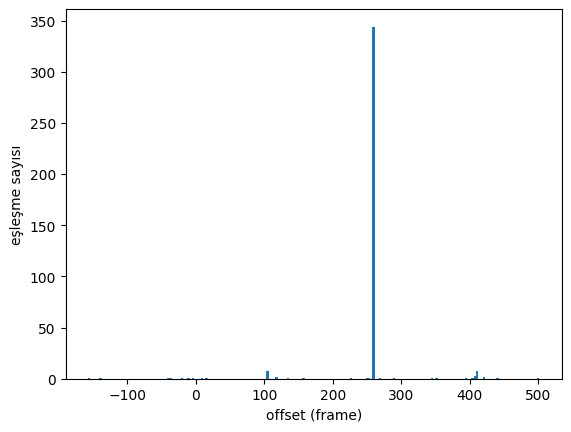

In [77]:
plt.hist(offsets, bins=200)
plt.xlabel("offset (frame)")
plt.ylabel("eşleşme sayısı")
plt.show()

Fakat bir problemimiz var. Problemden ziyade bir mantık:

Bizim şuan kullandığımız sentetik bir veri. Özetimiz ise full videonun tek bir dilimiydi. Bu yüzden tek bir doğru offset değeri ürettik.

Fakat gerçek bir senaryoda, bir full videodan farklı farklı özet klipleri olacaktır. Örn:

- Özetin 0–15. saniyesi → maçın 12. dakikasından
- Özetin 15–28. saniyesi → maçın 27. dakikasından
- Özetin 28–40. saniyesi → maçın 41. dakikasından

bu durumda her klip kendi offset değerine sahiptir. Yani tek doğru offset değil, onlarca doğru offset vardır. Sonuc olarak histogram yukarıdaki gibi tek bir tepe değeri değil çoklu tepe şeklinde gözükür, ki bu gayet doğaldır.

Bu sebeple most_common methodu artık kullanışsız. Yeni bir karar problemimiz var: Artık "en yüksek tepe hangisi?" değil, "hangi tepeler gerçek, hangileri gürültü?" diye soruyoruz. Yani bir eşik koyup "şu sayının üstündeki tüm offset'ler gerçek" diyeceğiz.

Bunun için 2 yaklaşım var

1. Histogram Eşiği (basic one):

```
güçlü_offsetler = {off for off, sayı in Counter(offsets).items() if sayı > EŞİK}
```
**belli bir sayının üstünde oy alanları tut, gerisini at.**

Fakat 2 zaafı var:
  - Eşik değeri veriye göre çok değişiyor. Bazı veride 300 işe yararken, bazılarında 500. Çok kırılgan

  - Offseti tek sabit bir değer varsayıyor. Yani bu yöntem "bir klibin tüm eşleşmeleri birebir aynı offset'i verir" varsayar. Ama gerçekte tam öyle değildir. Neden? İki kayıt farklı encode'lardan geçtiği için zaman ekseni hafifçe gerilmiş/sıkışmış olabilir (clock drift). Yani özetin 10. saniyesi full'ün 100'üyse, 20. saniyesi tam 110 değil, belki 110.3 olur — çok küçük bir kayma birikir.

2. RANSAC - Detaylıca bakalım


# RANSAC

Problemi yeniden inceleylim:

elimizde mathes listesi var: (ozet_zamanı, full_match_zamanı) çiftlerinden olusan binlerce nokta.

- Gerçek eşleşmeler: bir highlight klibine ait. O klip boyunca özet ve full aynı hızda ilerlediği için, bu noktalar eğimi 1 olan bir doğru parçası üzerine dizilir. Her klip bir "merdiven basamağı."

- Sahte eşleşmeler (collision): rastgele offset'ler, düzleme rastgele saçılmış.

Aslında problemimiz gürültü bir nokta bulutunda eğimi yaklaşık olarak 1 olan doğru parçalarını bulmaya evrildi..

**RANSAC temelde şunu der:** Belki verinin çoğu gürültü. O zaman tüm veriyi kullanmaya çalışma. Bunun yerine küçük rastgele örnekler al, her birinden bir model kur, ve hangi modelin en çok destek (consensus) topladığına bak.

Burada 2 anahtar kavramımız var:

- Inlier: modele uyan nokta (gerçek eşleşme)
- Outlier: modele uymayan nokta (gürültü)

**RANSAC**'ın tüm amacı inliner'ı outlier'dan ayırmak. Hatta outlier baskın olsa bile.

Önce kodu biraz inceleyelim:

In [78]:
def ransac(matches, n_iter=3000, tolerance=20):
  matches = np.array(matches) # # x = t_hl, y = t_full

  x = matches[:, 0] # tüm highlights zamanları
  y = matches[:, 1] # tüm full zamanları

  best_count = 0
  best_model = None

  best_inlier_mask = np.zeros(len(matches), dtype=bool)

  for _ in range(n_iter):
    idx = np.random.choice(len(matches), 2, replace=False)
    dot1 = matches[idx[0]]
    dot2 = matches[idx[1]]

    if (dot2[0] - dot1[0]) == 0: # egim hesabında .. / 0 olmaması icin
      continue

    slope = (dot2[1] - dot1[1]) / (dot2[0] - dot1[0])

    if not(0.9 < slope < 1.1): # egim yakın degilse adayı ele
      continue


    intersection = dot1[1] - slope * dot1[0]

    y_pred = slope * x + intersection # her nokta icin prediction

    distance = np.abs(y - y_pred) # her noktaya olan uzaklıgı

    inlier_mask = distance < tolerance # belirli bir toleranstan yakın olanlar

    inlier_count = np.sum(inlier_mask) # kac tane yakın deger var ise

    if inlier_count > best_count:
      best_count = inlier_count
      best_inlier_mask = inlier_mask
      best_model = (slope, intersection)

  return best_model, best_inlier_mask


# Klasik RANSAC "en güçlü tek modeli" döndürür.
# Ama bize onlarca basamak istiyoruz (her klip bir basamak).
# Çözüm: sequential RANSAC — bul, çıkar, tekrarla.

def sequential_ransac(matches, max_turns=30, MIN_INLIER = 50, MAX_X_ARALIGI=5000):
    remain = np.array(matches)
    segments = []

    for _ in range(max_turns):
        # Kalan havuzda en güçlü basamağı bul.
        # ransac maske döndürüyor (nokta değil)
        # — bu kritik, çünkü çıkarmayı ~mask ile temiz yapmanı sağlıyor. ✓
        model, inlier_mask = ransac(remain)
        inlier_count = np.sum(inlier_mask)


        # Durma koşulu: bu turda bulunan basamak zayıfsa,
        # artık gerçek basamak kalmamış demektir → dur.
        # Gürültüden RANSAC yine bir doğru uydurur ama az inlier'la;
        # işte o azlık "bitti" sinyali. ✓
        if inlier_count < MIN_INLIER:
            break

        segment = remain[inlier_mask]
        x_araligi = segment[:, 0].max() - segment[:, 0].min()
        remain = remain[~inlier_mask]


        if x_araligi < MAX_X_ARALIGI:
            segments.append(segment)

    return segments





Kodu 4 adımda inceleyelim:

Tek bir doğru (basamak) bulmak için RANSAC şunu çok kez tekrarlar:

Adım 1 — Rastgele minimum örnek seç.

Bir doğru tanımlamak için kaç nokta gerekir? İki. RANSAC bulutten rastgele 2 nokta seçer.

Neden minimum ve neden rastgele? Çünkü gürültü baskın. Çok nokta alıp ortalama alsaydın (least squares gibi), gürültü işe karışırdı. Minimum sayıda nokta seçip "belki bu ikisi gerçektir" diye şansını denersin. Rastgele, çünkü hangi noktaların gerçek olduğunu önceden bilmiyorsun.


```
idx = np.random.choice(len(matches), 2, replace=False)
dot1 = matches[idx[0]]
dot2 = matches[idx[1]]
```


Adım 2 — Modeli kur.
Seçtiğin 2 noktadan geçen doğruyu hesapla: eğim ve kesişim.


```
slope = (dot2[1] - dot1[1]) / (dot2[0] - dot1[0])
intersection = dot1[1] - slope * dot1[0]
```


Bu, "belki bir basamak budur" hipotezin.

Adım 3 — Consensus say (inlier'ları bul).
Şimdi tüm nokta bulutuna bak. Her nokta için sor: "bu nokta kurduğum doğruya yeterince yakın mı?"

Yakınlık ölçüsü: noktanın gerçek y'si ile doğrunun o x'te öngördüğü y arasındaki fark:


```

y_pred = slope * x + intersection # her nokta icin prediction

distance = np.abs(y - y_pred) # her noktaya olan uzaklıgı

inlier_mask = distance < tolerance # belirli bir toleranstan yakın olanlar

inlier_count = np.sum(inlier_mask) # kac tane yakın deger var ise
```



Adım 4 — Tekrarla, en iyiyi sakla.

`Adım 1-3'ü yüzlerce/binlerce kez tekrarla. Her seferinde farklı rastgele 2 nokta → farklı doğru → farklı inlier sayısı. En çok inlier toplayan doğruyu sakla.`

Peki bu neden işe yarıyor? — olasılık sezgisi

Rastgele 2 nokta seçtiğinde iki ihtimal var:

İkisi de aynı gerçek basamaktan: kurduğun doğru o basamağa oturur → o basamağın tüm noktaları inlier olur → yüksek consensus (yüzlerce).

En az biri gürültü: kurduğun doğru rastgele bir yöne gider → ona uyan nokta neredeyse yok → düşük consensus (birkaç).

Yeterince deneme yaparsan, er ya da geç "ikisi de gerçek" durumu yakalanır ve yüksek consensus verir. Gürültüden geçen doğrular hiçbir zaman yüksek consensus toplayamaz — çünkü gürültü dağınık, hiçbir doğruda birikemez.

Bu, offset consensus'un iki boyutlu versiyonu: orada "aynı offset'e oy verenler", burada "aynı doğruya yakın olanlar."

# Segments -> Labels

Elimizde segmentler var. Her segment bir nokta kümesi. Bu segmentler özü şu:

**Maçın hangi zaman aralığı özete girdi**

Bizim istediğimiz ise full maç'ın her frame için bir önem skoru üretmek. yani 1.3m uzunlugunda 0-1 arası değerler taşıyan bir dizi.

mantık:
  - 1: çok önemli sahne -> özete dahil et
  - 0: önemsiz sahne -> özete dahil etme

Fakat burada ince bir trick var. Önce elimizde ne olağına bakalım:



```
0 0 0 0 ... 0 1 1 1 1 1 1 0 0 0 ... 0 1 1 1 1 0 0 0 ...
              ↑ segment 1 ↑           ↑ segment 2 ↑
```
Yani keskin dikdörtgen bloklar. Bir frame önemsiz (0), bir sonraki aniden önemli (1), sonra tekrar 0. Sert geçişler.

Burada sorun klibi seçerken bu kadar sert geçişler yapamayız. Gol kadar pozisyonun hazırlanması da öneme sahiptir.

Keskin dikdörtgen bunu yansıtmıyor. "Bu frame tam olarak %100 önemli, bir sonraki tam olarak %0 önemsiz" diyor — ki gerçekçi değil. Önem, bir zirve etrafında kademeli azalır. Çan eğrisi bunu modellemenin doğal yolu.

Ayrıca TripleSumm gibi modeller daha yumusak geçisleri severler.

ve Sorun 3: Hizalama kusursuz değil.

Bu sorunları çözmek için **Gaussian smoothing** kullanacağız.

Peki Gaussian Smoothing ne yapar:

Fikir: her noktanın değerini, komşularının ağırlıklı ortalamasıyla değiştir. Ağırlıklar bir çan eğrisinden (Gaussian) gelir — yakın komşular çok, uzaklar az katkı verir.


```
Önce:  0 0 0 1 1 1 1 1 0 0 0
Sonra: 0 .1 .4 .8 1 1 1 .8 .4 .1 0
```








In [79]:
import numpy as np
from scipy.ndimage import gaussian_filter1d

def segments2label(segments, fullMatch_length):

    araliklar = []
    labels = np.zeros(fullMatch_length) # 1-0 dolduracagiz
    smooth_labels = None

    for seg in segments:
        fullMatch_start = int(seg[:, 1].min()) # np.float dönüyor, sıkıntı yaratabilir.
        fullMatch_end = int(seg[:, 1].max())

        labels[fullMatch_start: fullMatch_end] = 1


        araliklar.append((fullMatch_start, fullMatch_end))

    smooth_labels = gaussian_filter1d(labels, sigma=300)

    return smooth_labels, araliklar

# Summary

elimizde bir maçın tam kaydı ve hazır özeti vardı; özetin her parçasının maçta nereye düştüğünü sesten otomatik bulduk, ve bundan "maçın hangi anı ne kadar önemli" etiketini ürettik. Editörün özeti hazırlarken verdiği kararı, geriye doğru çözüp makine öğrenmesi için kullanılabilir bir sinyale çevirdik.

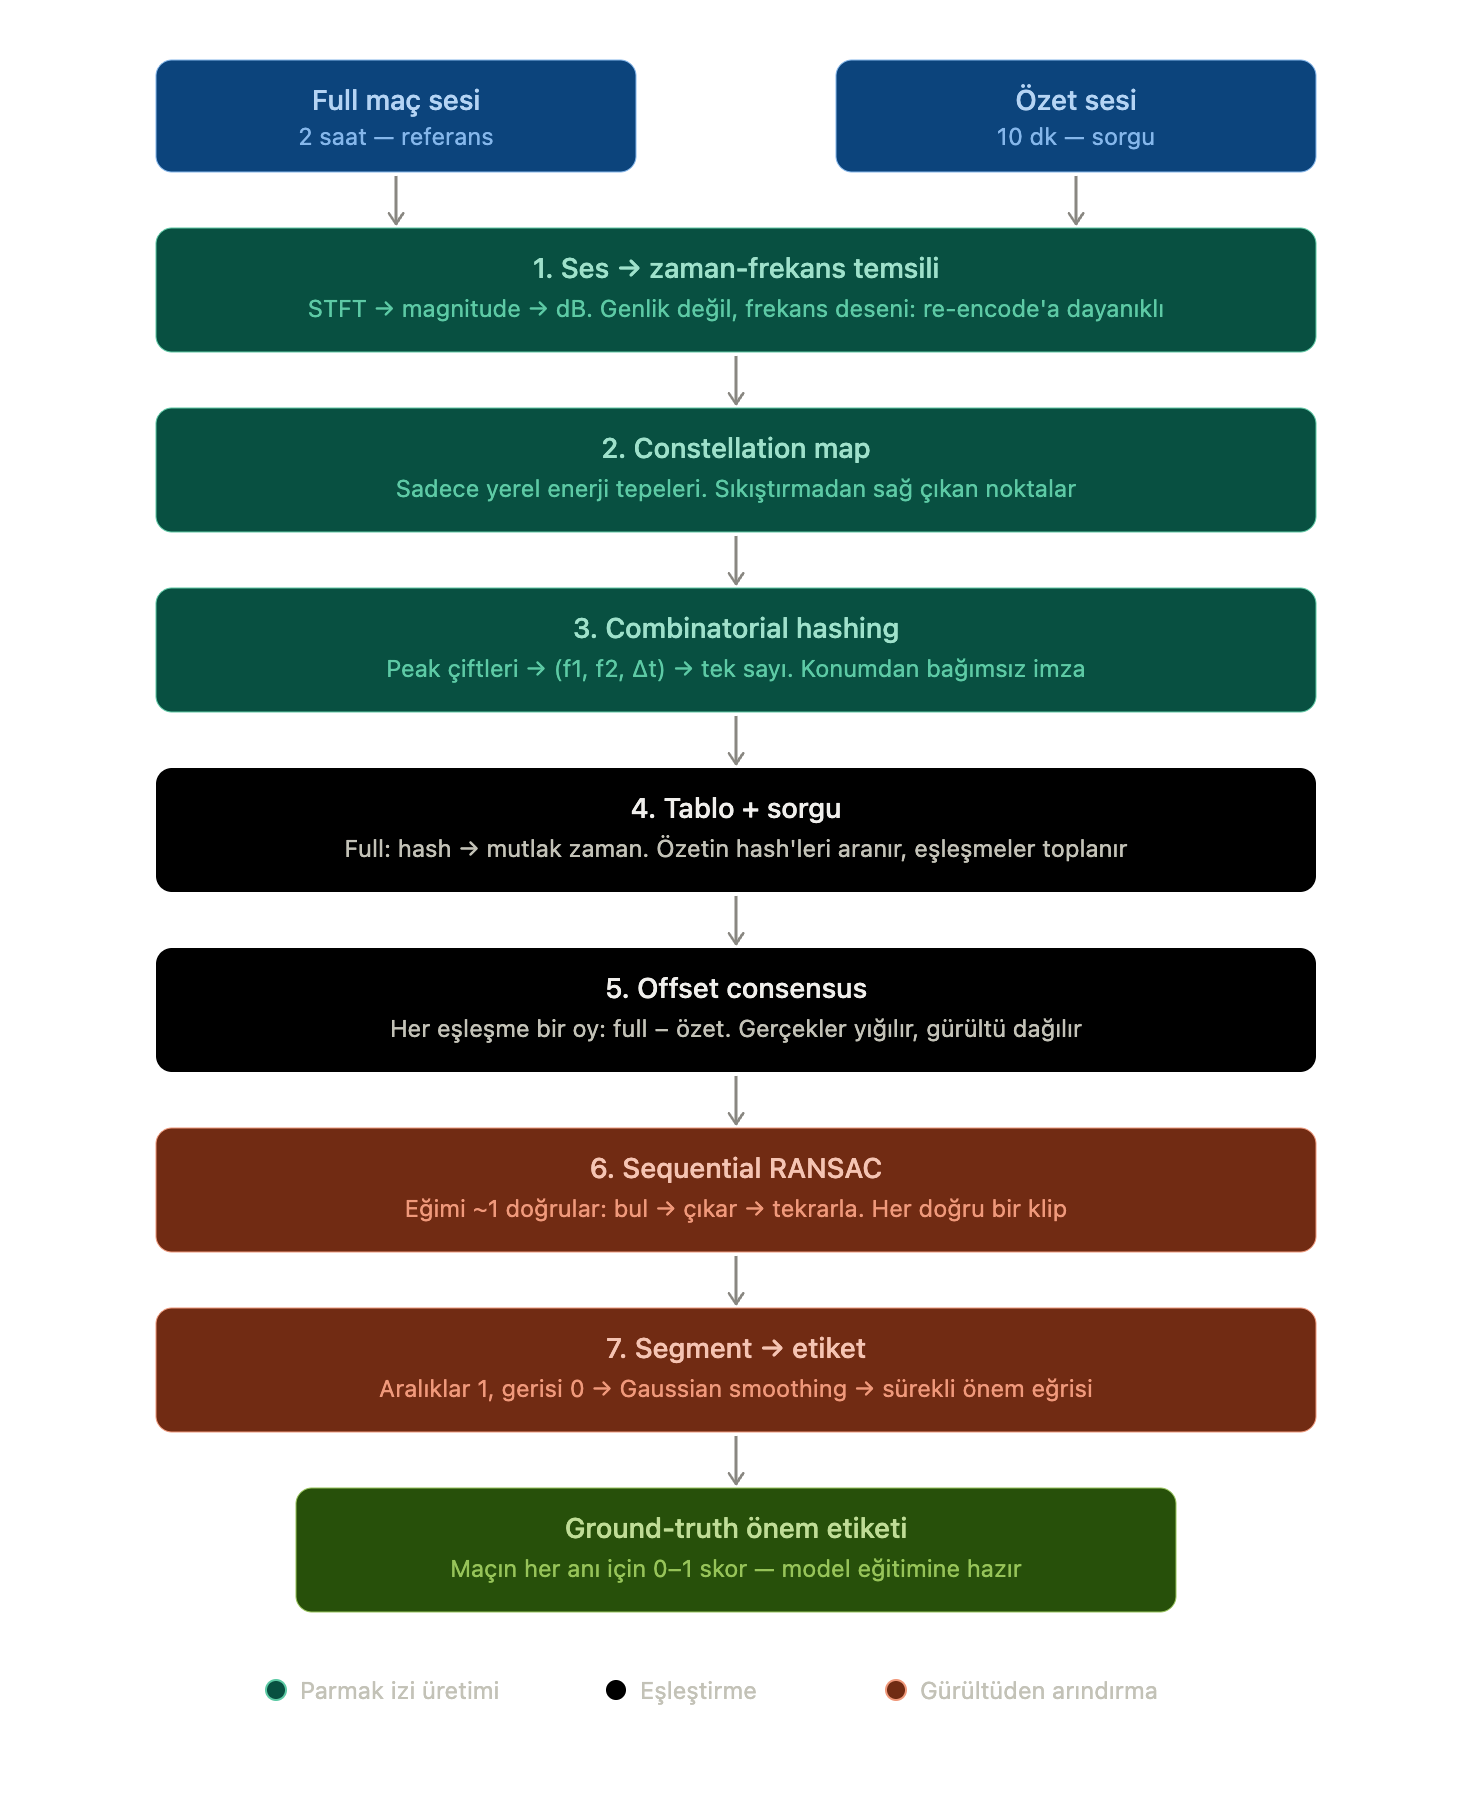


**hazır bir özetten, elle etiketleme yapmadan, model eğitimi için kullanılabilir ground-truth üretmek.**